The bad result is:
{}


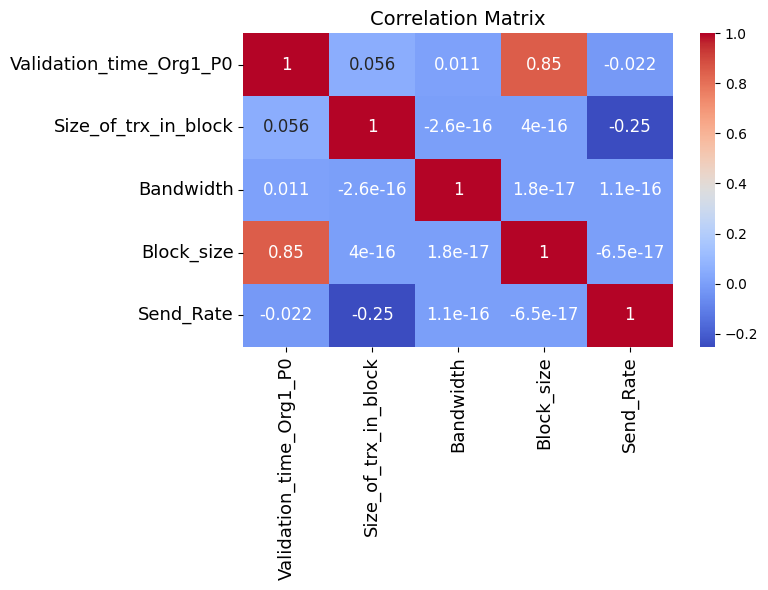

Correlation with 'Validation_time_Org1_P0':
Validation_time_Org1_P0    1.000000
Block_size                 0.848775
latancy                    0.773433
Size_of_trx_in_block       0.055692
Bandwidth                  0.011214
Send_Rate                 -0.022100
throuout                  -0.787853
Name: Validation_time_Org1_P0, dtype: float64

Feature Importances:
                Feature  Importance
2            Block_size    0.984075
3             Send_Rate    0.007232
0  Size_of_trx_in_block    0.004418
1             Bandwidth    0.004275

Top 2 Features:
['Block_size', 'Send_Rate']


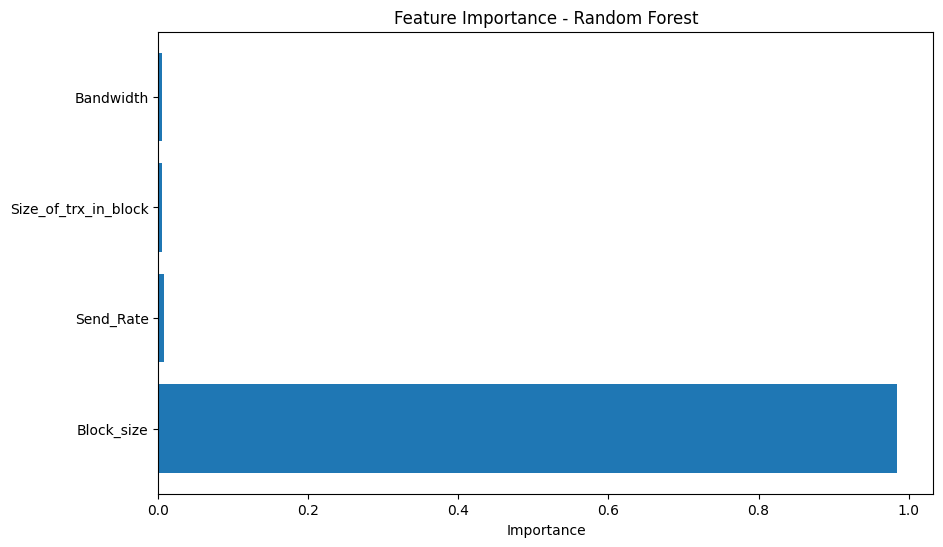

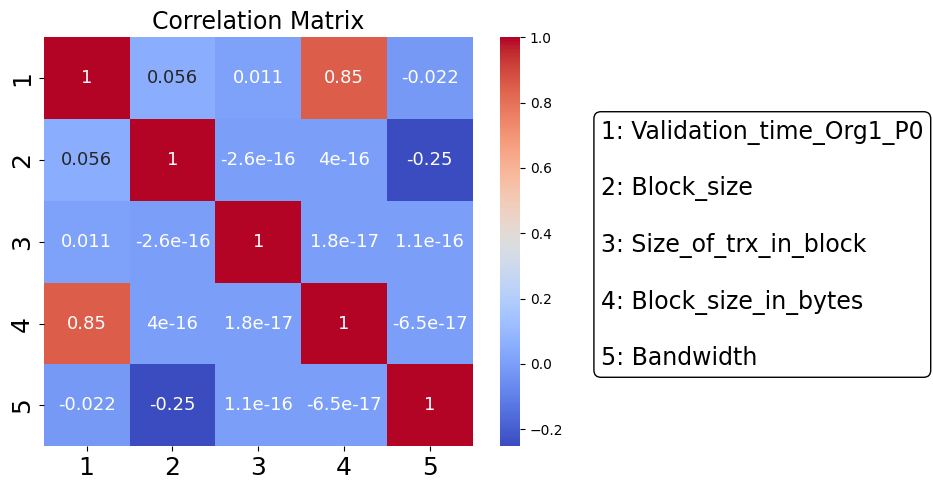

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'pdf.fonttype': 42})
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# ---- Your dataset ----
data = {


     "Size_of_trx_in_block": [2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                              
                            2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                              
                              4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                              
                              4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                             
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                              
                              # 8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              #  8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              #  8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              #  8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              #  8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              #  8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              
                              #   8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              #  8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              #  8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              #  8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              #  8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              #  8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                    
                             
                             
                             
                        ],
    "Bandwidth": [1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                   5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                   20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  
                  #         1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  # 1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  # 1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  # 1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  # 1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  # 1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  #   5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  # 5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  # 5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  # 5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  # 5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  # 5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
 
                 ],
    "Block_size":[2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                    2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                   2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                  
                   2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                    2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                  #   2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  # 2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  # 2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  # 2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  # 2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  # 2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                  
                  #   2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  # 2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  # 2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  # 2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  # 2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  # 2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                 ],
    "Send_Rate":[10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,
                 300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,
                 
                 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,
                 300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,
                 
             
                 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,
                 300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,
                 
                 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                  10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                    10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                 #  10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 # 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 # 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 # 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 # 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 # 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                 # 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 # 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 # 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 # 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 # 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 # 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
             
             
                ],


     
       "Validation_time_Org1_P0": [0.001600913,
0.002244816,
0.003105428,
0.003932622,
0.004529645,
0.005397699,
0.006327499,
0.007420418,
0.007759922,
0.007248702,
0.008742626,
0.010875304,
0.011736749,
0.010612183,
0.012473136,
0.002296077,
0.003252283,
0.00373709,
0.00443503,
0.005660162,
0.006772544,
0.007603915,
0.00784266,
0.008682528,
0.008754635,
0.009427513,
0.011516874,
0.010988177,
0.010538066,
0.01094859,
0.001593864,
0.002260066,
0.002961854,
0.003853936,
0.004476557,
0.005845434,
0.006539429,
0.007086954,
0.00820233,
0.007062471,
0.008720683,
0.011146202,
0.010352842,
0.010059902,
0.011029911,
0.001522381,
0.002247529,
0.003197273,
0.003778545,
0.004797104,
0.006133759,
0.0063159,
0.006835185,
0.008619578,
0.007561889,
0.008616248,
0.011174956,
0.011560967,
0.01017711,
0.011874132,
0.001522237,
0.002343817,
0.002854569,
0.003583472,
0.004678882,
0.005527834,
0.006451657,
0.007424138,
0.007957372,
0.006847042,
0.008590417,
0.011184007,
0.010715029,
0.011254389,
0.011092801,
0.001571257,
0.002172689,
0.00319135,
0.003601474,
0.004428396,
0.005228087,
0.006829034,
0.007020296,
0.008266954,
0.006816354,
0.008977835,
0.010739351,
0.011114087,
0.010924413,
0.010421791,
0.001718599,
0.002317041,
0.002990381,
0.003540104,
0.004561561,
0.00601955,
0.006145073,
0.006931724,
0.008404243,
0.008134648,
0.007805059,
0.010247492,
0.011911954,
0.011119319,
0.012122616,
0.001557852,
0.0022319,
0.00324418,
0.003911061,
0.004188062,
0.005402311,
0.00700177,
0.007340275,
0.008229092,
0.00706244,
0.008951106,
0.010823258,
0.011050317,
0.011817499,
0.011455708, 
                                   
                                   0.001483651,
0.002368965,
0.00327232,
0.003853793,
0.004540776,
0.00512379,
0.00659019,
0.006431467,
0.007709821,
0.00750592,
0.008576897,
0.011358031,
0.011254846,
0.010389886,
0.012383826,
0.001658436,
0.002345781,
0.00318162,
0.003487925,
0.004435436,
0.005615919,
0.00603607,
0.006898929,
0.007837113,
0.006982258,
0.008197616,
0.011092937,
0.011516152,
0.010572845,
0.011952597,
0.001658436,
0.002345781,
0.00318162,
0.003487925,
0.004435436,
0.005615919,
0.00603607,
0.006898929,
0.007837113,
0.006982258,
0.008197616,
0.011092937,
0.011516152,
0.010572845,
0.011952597,
0.001661051,
0.002327871,
0.002949865,
0.003953857,
0.004833767,
0.005478851,
0.006255202,
0.006982367,
0.007859813,
0.00742105,
0.007654889,
0.010286221,
0.010781233,
0.010040534,
0.011510162,
0.001592463,
0.002391885,
0.003206055,
0.003732037,
0.004737507,
0.005458876,
0.006116585,
0.006945032,
0.007788009,
0.006660809,
0.008903725,
0.011528354,
0.010866199,
0.011189188,
0.011248562,
0.001656527,
0.002238053,
0.003129338,
0.004006226,
0.004540287,
0.005300848,
0.006753608,
0.00703853,
0.008225134,
0.007681651,
0.008520537,
0.011571022,
0.011505393,
0.010789289,
0.011172977,
0.001645989,
0.002293144,
0.003046214,
0.003682297,
0.004342844,
0.005744852,
0.006792537,
0.006930758,
0.007389283,
0.00708223,
0.008055813,
0.011185566,
0.011446427,
0.011335464,
0.010450668,
0.00162729,
0.002330426,
0.002870342,
0.003375231,
0.004479849,
0.005624363,
0.00627132,
0.007021553,
0.007311915,
0.007261124,
0.008043554,
0.010609246,
0.011933029,
0.010623064,
0.010722621,
                                   0.001618426,
0.002246851,
0.003152819,
0.003462837,
0.004655155,
0.00560753,
0.007378863,
0.007205596,
0.007975801,
0.007594883,
0.008548131,
0.010886332,
0.012776712,
0.011301145,
0.011638274,
0.001632191,
0.002317549,
0.003272056,
0.003778085,
0.004640148,
0.005820528,
0.006681788,
0.006424223,
0.007983255,
0.007258202,
0.008178912,
0.011382905,
0.011388214,
0.011866343,
0.012311944,
0.001815392,
0.002462884,
0.003523363,
0.004074795,
0.004807958,
0.00558051,
0.00667422,
0.007268164,
0.007617301,
0.007847803,
0.008428194,
0.010679915,
0.012050404,
0.012497546,
0.012301426,
0.001682736,
0.002363095,
0.00301985,
0.003880659,
0.004940854,
0.005457808,
0.006518542,
0.007483061,
0.007668677,
0.007330524,
0.008333999,
0.01132909,
0.012587864,
0.011131665,
0.012178899,
0.001581125,
0.002483219,
0.003127192,
0.003954097,
0.005024859,
0.005616708,
0.006472857,
0.007039406,
0.007766509,
0.007931188,
0.008597581,
0.011354071,
0.010287865,
0.012756662,
0.010733827,
0.001728825,
0.002438718,
0.003201684,
0.004024236,
0.004630073,
0.005231684,
0.006029029,
0.006846504,
0.008181659,
0.007564753,
0.008443141,
0.010284942,
0.011580168,
0.011767239,
0.011504006,
0.001647082,
0.00223282,
0.003071138,
0.003627808,
0.004471573,
0.005599518,
0.007038787,
0.006796658,
0.007498638,
0.007370445,
0.009042053,
0.010688153,
0.011648015,
0.01188057,
0.012319858,
0.001618343,
0.002241334,
0.003211623,
0.003693523,
0.004483555,
0.005464029,
0.006433695,
0.007685764,
0.008760606,
0.00748463,
0.008498358,
0.011651956,
0.011953514,
0.011562121,
0.012324949,
                                   0.001676921,
0.002619922,
0.003414241,
0.003870842,
0.004901061,
0.005809088,
0.006512711,
0.007488596,
0.008711786,
0.008043818,
0.008884023,
0.011808178,
0.011847203,
0.012033987,
0.012821493,
0.001723797,
0.002501722,
0.003311792,
0.004007998,
0.004927711,
0.006104079,
0.006331537,
0.007798908,
0.008186399,
0.008223193,
0.008929096,
0.011093092,
0.011326665,
0.011955399,
0.012632989,
0.001742874,
0.002480405,
0.00333831,
0.004051177,
0.004918398,
0.005558727,
0.006659279,
0.007434781,
0.007890224,
0.008067569,
0.009002452,
0.011430782,
0.011789458,
0.011727187,
0.01303244,
0.001673984,
0.002385025,
0.003259419,
0.003753394,
0.004687472,
0.006292449,
0.007101695,
0.007617274,
0.00814253,
0.00803186,
0.008818355,
0.010623244,
0.012523167,
0.012852981,
0.012753095,
0.001754148,
0.002531713,
0.003447404,
0.004144979,
0.004711477,
0.005981965,
0.006596972,
0.007322444,
0.008030798,
0.00782054,
0.009656533,
0.011272623,
0.012534788,
0.012463609,
0.013164924,
0.00173337,
0.002520015,
0.003336889,
0.00398431,
0.004677712,
0.005648646,
0.006408767,
0.007510184,
0.007999284,
0.008103336,
0.008862447,
0.0110639,
0.01220759,
0.011792782,
0.012685614,
                                   0.001685264,
0.002515211,
0.003213206,
0.003957672,
0.004924619,
0.006168344,
0.006371029,
0.007886553,
0.007813948,
0.007880242,
0.009439828,
0.011240026,
0.01075563,
0.011455117,
0.011805128,
0.001684593,
0.002480555,
0.003327953,
0.003791037,
0.004559757,
0.006463094,
0.006842008,
0.00771159,
0.009112574,
0.00785101,
0.008786647,
0.011332222,
0.011851668,
0.012328191,
0.011770738,
0.001720291,
0.002647063,
0.003550588,
0.004354883,
0.004939723,
0.006457779,
0.007035715,
0.007983114,
0.008590616,
0.008723344,
0.009266361,
0.011975824,
0.01241474,
0.011488976,
0.011875525,
0.001763757,
0.002270126,
0.003265076,
0.004164909,
0.005065837,
0.005897528,
0.006308779,
0.007357634,
0.007494434,
0.007741221,
0.009154939,
0.011177138,
0.012298632,
0.012272601,
0.012201018,
0.001689631,
0.002521519,
0.003292565,
0.00417599,
0.004842898,
0.005827566,
0.006632034,
0.006970226,
0.008138045,
0.008081848,
0.008797434,
0.01117313,
0.012166563,
0.012484587,
0.011741956,
0.001753574,
0.002412695,
0.003195409,
0.003893454,
0.005084478,
0.005770258,
0.0069979,
0.007004467,
0.008266605,
0.008441435,
0.009515224,
0.011357783,
0.011770121,
0.011112057,
0.011866842,
                                   0.001748212,
0.002558183,
0.003205894,
0.003763866,
0.004648587,
0.005748771,
0.006720568,
0.00757501,
0.008482166,
0.008010313,
0.009160013,
0.01093434,
0.010682821,
0.011804646,
0.01215121,
0.001676359,
0.002589464,
0.003322677,
0.003897678,
0.004998874,
0.006328166,
0.006893938,
0.006859076,
0.008145484,
0.007574217,
0.009329384,
0.011198582,
0.012460558,
0.013712896,
0.012561921,
0.001735926,
0.002646717,
0.003435304,
0.003942962,
0.004503753,
0.005634966,
0.006679775,
0.007125099,
0.008382727,
0.007866159,
0.008918337,
0.011239104,
0.012426699,
0.011878002,
0.012657694,
0.001878931,
0.002479383,
0.003516432,
0.004867607,
0.005373006,
0.006427675,
0.007153173,
0.007654574,
0.008110187,
0.008727915,
0.010334488,
0.012051704,
0.011743551,
0.010690283,
0.012197797,
0.001744604,
0.002543468,
0.003300728,
0.00363116,
0.004893046,
0.005568683,
0.006923902,
0.007313144,
0.008266503,
0.007367099,
0.009593909,
0.011531908,
0.012353401,
0.01095499,
0.01312603,
0.001741524,
0.00233342,
0.003302265,
0.004083359,
0.005018524,
0.005975143,
0.0064103,
0.007636434,
0.007812633,
0.007199234,
0.008826323,
0.011976169,
0.011957211,
0.011626427,
0.011623682,
#                                    0.001923118,
# 0.002968517,
# 0.004251586,
# 0.004719819,
# 0.005533288,
# 0.006740065,
# 0.007524308,
# 0.00798202,
# 0.008664022,
# 0.007970191,
# 0.010724,
# 0.013189925,
# 0.011700657,
# 0.011413065,
# 0.011832857,
# 0.00189336,
# 0.002755523,
# 0.003929421,
# 0.00472173,
# 0.005341223,
# 0.006558142,
# 0.007711804,
# 0.008556207,
# 0.009605948,
# 0.008530417,
# 0.009756301,
# 0.012202945,
# 0.012943732,
# 0.012817272,
# 0.011922124,
# 0.001817262,
# 0.00270598,
# 0.003628059,
# 0.004368298,
# 0.005629697,
# 0.006249597,
# 0.007474699,
# 0.008097815,
# 0.008591936,
# 0.009264832,
# 0.010020358,
# 0.012744732,
# 0.011446551,
# 0.012893342,
# 0.011839214,
# 0.001883599,
# 0.002690679,
# 0.003568002,
# 0.004453163,
# 0.005196709,
# 0.006388,
# 0.007376299,
# 0.007794212,
# 0.008842741,
# 0.009122345,
# 0.01003309,
# 0.012736137,
# 0.012200116,
# 0.011945204,
# 0.010961666,
# 0.001899821,
# 0.002740684,
# 0.003494447,
# 0.004649828,
# 0.005253215,
# 0.006033805,
# 0.007338324,
# 0.008400198,
# 0.008948976,
# 0.008531314,
# 0.010289976,
# 0.01304796,
# 0.012186948,
# 0.011921687,
# 0.012227452,
# 0.001865463,
# 0.002940401,
# 0.003733916,
# 0.004139815,
# 0.005366553,
# 0.006587378,
# 0.006958002,
# 0.008217545,
# 0.008296167,
# 0.008700562,
# 0.01022593,
# 0.012918439,
# 0.011137897,
# 0.01304251,
# 0.012764032, 
#                                    0.001987399,
# 0.003415725,
# 0.004163665,
# 0.004256314,
# 0.005176375,
# 0.007079294,
# 0.007517827,
# 0.008820932,
# 0.009310707,
# 0.008312,
# 0.009692712,
# 0.012845126,
# 0.011312671,
# 0.011397975,
# 0.012714971,
# 0.001837616,
# 0.002725564,
# 0.003858881,
# 0.004743759,
# 0.005357095,
# 0.006539039,
# 0.007209965,
# 0.008208875,
# 0.008515144,
# 0.007873334,
# 0.009478276,
# 0.011659403,
# 0.01167936,
# 0.01178484,
# 0.014111856,
# 0.001785789,
# 0.002666185,
# 0.003574803,
# 0.004418363,
# 0.005433364,
# 0.006435337,
# 0.007580107,
# 0.008465982,
# 0.008366716,
# 0.008499657,
# 0.009729277,
# 0.01217982,
# 0.012777274,
# 0.010962082,
# 0.012457331,
# 0.00197643,
# 0.002584178,
# 0.00382487,
# 0.004659283,
# 0.005499875,
# 0.006124628,
# 0.007866504,
# 0.00888315,
# 0.008602886,
# 0.009528728,
# 0.010001165,
# 0.01169225,
# 0.012002644,
# 0.011546038,
# 0.012106355,
# 0.001865765,
# 0.002575505,
# 0.00370601,
# 0.004317356,
# 0.005367949,
# 0.006675113,
# 0.007569676,
# 0.008468913,
# 0.00875089,
# 0.008876623,
# 0.01000507,
# 0.011483224,
# 0.012072715,
# 0.011884199,
# 0.011884903,
# 0.00194242,
# 0.002759021,
# 0.003819704,
# 0.004348713,
# 0.005732462,
# 0.006641571,
# 0.006949978,
# 0.007856591,
# 0.008263546,
# 0.008400705,
# 0.010792843,
# 0.011739314,
# 0.012412925,
# 0.011304366,
# 0.013276558,
                                   
                               ],
    
    
    
    
    
        "throuout":[35,
35,
32.4,
28.9,
34.8,
56.9,
23.4,
24.4,
21.7,
14.8,
5,
2.2,
0.7,
0.6,
0.6,
33.1,
33.3,
31.7,
28.5,
32.1,
68.5,
24.4,
24.9,
24.9,
12.5,
4.2,
2.1,
0.7,
0.6,
0.7,
35,
35.4,
31.5,
29.4,
33.3,
57,
25.1,
22.2,
19.5,
10.6,
5.2,
2.1,
0.7,
0.7,
0.7,
35.1,
35.2,
31.1,
27.8,
33.3,
53.4,
25,
22.3,
21.6,
19.7,
6,
2.2,
0.7,
0.7,
0.6,
34.9,
35.1,
32.5,
26.7,
34.4,
52.3,
28.1,
23.2,
23.8,
16.2,
5.1,
1.5,
0.6,
0.7,
0.6,
35.1,
35.2,
31.6,
28.5,
34.7,
46.3,
25.7,
26.5,
25.4,
16,
3.7,
2.1,
0.7,
0.6,
0.6,
35.2,
35,
31.8,
25.7,
33.6,
67.6,
24.3,
24.3,
24,
16.5,
5.3,
2.2,
0.7,
0.6,
0.7,
35.2,
35.4,
31.6,
27.6,
34.5,
70.5,
26.2,
24.2,
21.4,
13.5,
5.6,
2.2,
0.6,
0.6,
0.7,
                    
                    34.6,
35.2,
31.7,
29.3,
33.8,
76.9,
24.7,
26.9,
24,
15.5,
3,
2.2,
0.6,
0.7,
0.6,
35.1,
35.4,
32.2,
30.6,
34.5,
72.8,
26.8,
26.3,
23.9,
12.9,
3.7,
1.4,
0.6,
0.6,
0.7,
35.1,
35.4,
32.2,
30.6,
34.5,
72.8,
26.8,
26.3,
23.9,
12.9,
3.7,
1.4,
0.6,
0.6,
0.7,
35,
35.1,
32.3,
27.4,
34.5,
64.9,
11.9,
25.9,
20.4,
12.8,
3.7,
2.2,
0.7,
0.7,
0.7,
34.9,
35,
31.9,
26.7,
33.1,
65,
26.4,
24.1,
17.7,
14.7,
2.8,
1.5,
0.7,
0.7,
0.7,
35.1,
34.8,
32.1,
27.3,
34.5,
55.2,
26,
26.2,
23,
17.8,
5.7,
2.2,
0.7,
0.7,
0.6,
35,
35.2,
32.8,
29.8,
34.5,
51.9,
24.7,
27.1,
23.8,
16.6,
3.7,
1.5,
0.7,
0.6,
0.7,
35,
34.9,
33,
27.7,
34.8,
63.4,
27,
25.7,
21.2,
18.6,
5.3,
2.2,
0.7,
0.7,
0.7,
                    35.4,
35.3,
31.8,
29.2,
34.6,
51.9,
26.5,
25.9,
22.7,
15.5,
3.3,
2.2,
0.7,
0.6,
0.6,
34.9,
35.1,
32.6,
27,
33.4,
59.7,
26.5,
18.7,
22.6,
12.5,
3,
1.5,
0.6,
0.7,
0.7,
33.9,
34.5,
32,
27.8,
33.4,
43.6,
23.4,
27.4,
13.2,
16.8,
4.1,
1.4,
0.7,
0.7,
0.6,
34.7,
34.7,
32.4,
29.7,
34.2,
74.8,
25.8,
24.5,
19.4,
19.3,
4.8,
2.2,
0.7,
0.7,
0.6,
34.9,
35.2,
31.5,
29.8,
34.6,
59.9,
29.5,
22.6,
22,
19.2,
4.2,
1.4,
0.7,
0.6,
0.6,
34.5,
35.1,
32.5,
30,
33.6,
64.7,
27.1,
20.6,
25.4,
18.5,
5.2,
2.2,
0.7,
0.7,
0.7,
34.6,
35.2,
32.3,
28.4,
34.7,
64.3,
25.4,
19.5,
24.1,
14.7,
6.7,
2.1,
0.7,
0.7,
0.7,
35,
35.2,
32.1,
29.4,
34.3,
63.1,
23.7,
17.1,
21.6,
15.3,
3.5,
2.1,
0.7,
0.7,
0.6,
                    34.6,
34.8,
32.3,
29,
34.3,
61.7,
27.9,
26.5,
24.6,
18.3,
3.7,
2.1,
0.6,
0.6,
0.7,
34.6,
34.8,
31.5,
29.7,
33.7,
28,
27,
23.3,
21.7,
17.8,
5.2,
2.1,
0.7,
0.6,
0.7,
34.2,
34.7,
31.6,
28.3,
33.3,
53.8,
26.5,
24.9,
25.5,
16.5,
3.1,
2.2,
0.6,
0.7,
0.7,
34.8,
34.9,
31.5,
29.2,
34.5,
64.4,
23.5,
23.1,
21.9,
14.1,
3.4,
2.2,
0.6,
0.7,
0.6,
34.7,
34.8,
30.7,
29.9,
33.1,
64.5,
24.3,
25.2,
25.4,
14.1,
7.4,
2.2,
0.7,
0.6,
0.6,
34.8,
34.8,
31.1,
28,
31.7,
88,
27,
21.5,
24.6,
17.3,
4.5,
1.5,
0.7,
0.7,
0.7,
                    34.6,
34.2,
32.2,
28.2,
33.2,
60.6,
24.3,
23.9,
24.8,
15.8,
6.2,
2.1,
0.6,
0.7,
0.7,
34.9,
35,
32.3,
28.8,
33.8,
60.2,
26.2,
25.6,
26,
16.3,
5.2,
2.2,
0.7,
0.6,
0.6,
34.5,
34.4,
31.2,
30.9,
33.8,
42.8,
26.5,
24.1,
25.4,
15,
4.6,
2.2,
0.7,
0.7,
0.7,
34.7,
34.6,
31.3,
28.5,
33.9,
61.7,
25.1,
25.9,
25.6,
15.2,
6,
2.1,
0.6,
0.7,
0.6,
34.6,
34.7,
31.6,
29.5,
31.9,
50.8,
28,
26.4,
25.3,
15.3,
4.3,
1.4,
0.6,
0.7,
0.7,
34.2,
34.7,
31.8,
30,
32.7,
53.4,
25.6,
26.3,
23.4,
16.3,
6.7,
2.1,
0.7,
0.7,
0.7,
                    34.7,
34.5,
31.4,
28.4,
33.7,
63.3,
24.3,
24,
20,
14.6,
7.5,
2.2,
0.7,
0.7,
0.7,
34.5,
34.6,
32.1,
28.3,
32.6,
66.5,
26.6,
25.6,
19.3,
13.9,
3.7,
2.1,
0.7,
0.6,
0.6,
34.4,
34.4,
32.1,
28.4,
34.1,
59.8,
26.6,
25.7,
22.2,
18.1,
4.2,
1.6,
0.7,
0.7,
0.6,
34,
34.4,
31.7,
25.4,
30.9,
32.7,
25.3,
24.3,
26.6,
11.8,
5.4,
2.1,
0.7,
0.7,
0.7,
34.5,
34.8,
32.3,
28,
34.1,
56.8,
25.4,
21,
20.4,
18.8,
4.2,
2.2,
0.7,
0.6,
0.7,
34.4,
34.8,
31.7,
27.7,
33.1,
65,
27,
20.8,
25.9,
17,
3.3,
1.4,
0.7,
0.7,
0.7,
#                     33.7,
# 32.5,
# 31.2,
# 27.2,
# 33.8,
# 66.5,
# 23.8,
# 25.7,
# 24.5,
# 12.7,
# 5.6,
# 2.1,
# 0.7,
# 0.6,
# 0.7,
# 34.4,
# 34.6,
# 31.6,
# 28.1,
# 31.9,
# 60.9,
# 25.5,
# 23.9,
# 23,
# 11.2,
# 4,
# 2.1,
# 0.6,
# 0.6,
# 0.7,
# 34.1,
# 33.9,
# 31.6,
# 27.8,
# 33.3,
# 55.6,
# 26.5,
# 24.4,
# 19.6,
# 12.5,
# 4.2,
# 2.1,
# 0.7,
# 0.7,
# 0.6,
# 34.1,
# 34,
# 31.9,
# 28.1,
# 32.5,
# 55.8,
# 20.5,
# 23.9,
# 22.1,
# 14.4,
# 8,
# 2.1,
# 0.7,
# 0.7,
# 0.7,
# 34.1,
# 34.3,
# 30.8,
# 28.4,
# 32.9,
# 13.3,
# 23.5,
# 25.6,
# 21.1,
# 12.5,
# 2.9,
# 1.5,
# 0.7,
# 0.7,
# 0.6,
# 34,
# 33.7,
# 31.8,
# 28.3,
# 31.7,
# 63.5,
# 26.5,
# 25.1,
# 21.5,
# 12.1,
# 4.4,
# 1.4,
# 0.6,
# 0.7,
# 0.7,
#                     33.3,
# 30.5,
# 30.3,
# 27.1,
# 30.9,
# 53.2,
# 23.9,
# 23.4,
# 24.9,
# 15.3,
# 4.1,
# 2.1,
# 0.6,
# 0.7,
# 0.6,
# 33.6,
# 34.4,
# 31.4,
# 27.3,
# 33.4,
# 64.1,
# 25.3,
# 24.3,
# 20.7,
# 15.2,
# 3.6,
# 2.1,
# 0.7,
# 0.7,
# 0.7,
# 34.3,
# 34.1,
# 30.9,
# 28.7,
# 33.5,
# 53.2,
# 25.5,
# 25,
# 21.4,
# 12.5,
# 5.7,
# 2.1,
# 0.7,
# 0.7,
# 0.7,
# 34.1,
# 34,
# 30.9,
# 29,
# 33.7,
# 64.4,
# 20.1,
# 23.7,
# 23.7,
# 18.4,
# 3.6,
# 2.1,
# 0.7,
# 0.6,
# 0.6,
# 34,
# 33.9,
# 30.7,
# 29.1,
# 33,
# 38.5,
# 26.6,
# 26.1,
# 21.9,
# 17.1,
# 4.2,
# 1.4,
# 0.7,
# 0.7,
# 0.7,
# 33.8,
# 33.9,
# 31.8,
# 27.1,
# 32,
# 42.7,
# 27.4,
# 25.9,
# 23.9,
# 16.4,
# 6,
# 2.2,
# 0.7,
# 0.7,
# 0.7,
               
               ],
    "latancy":[0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.15,
0.17,
0.19,
0.42,
1.28,
3.88,
12.51,
13.48,
13.49,
0.11,
0.12,
0.1,
0.11,
0.19,
0.1,
0.15,
0.17,
0.16,
0.52,
1.36,
4.09,
12.54,
13.45,
12.64,
0.09,
0.11,
0.09,
0.1,
0.18,
0.1,
0.14,
0.19,
0.22,
0.57,
1.19,
4.08,
12.48,
12.61,
12.87,
0.09,
0.11,
0.09,
0.1,
0.18,
0.11,
0.14,
0.19,
0.19,
0.3,
1.17,
3.9,
12.53,
12.7,
13.67,
0.09,
0.11,
0.09,
0.11,
0.17,
0.11,
0.12,
0.19,
0.17,
0.37,
1.2,
6.27,
13.12,
12.64,
13.35,
0.09,
0.11,
0.09,
0.1,
0.17,
0.12,
0.14,
0.16,
0.16,
0.39,
1.38,
4.01,
12.39,
13.65,
13.21,
0.09,
0.11,
0.09,
0.11,
0.17,
0.09,
0.14,
0.17,
0.17,
0.36,
1.15,
3.94,
12.47,
13.75,
12.56,
0.09,
0.11,
0.09,
0.11,
0.17,
0.09,
0.13,
0.18,
0.2,
0.45,
1.11,
3.85,
13.04,
13.74,
12.91,
               
               
               0.09,
0.11,
0.09,
0.1,
0.17,
0.08,
0.14,
0.15,
0.17,
0.38,
1.68,
3.8,
13.24,
12.68,
13.66,
0.09,
0.11,
0.09,
0.1,
0.17,
0.09,
0.13,
0.16,
0.17,
0.48,
1.41,
7.13,
13.06,
13.61,
12.87,
0.09,
0.11,
0.09,
0.1,
0.17,
0.09,
0.13,
0.16,
0.17,
0.48,
1.41,
7.13,
13.06,
13.61,
12.87,
0.09,
0.11,
0.09,
0.11,
0.18,
0.09,
0.31,
0.15,
0.2,
0.48,
1.37,
4.02,
12.48,
12.64,
12.91,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.13,
0.17,
0.25,
0.42,
1.57,
7.01,
12.4,
12.62,
12.79,
0.09,
0.11,
0.09,
0.11,
0.17,
0.1,
0.13,
0.16,
0.18,
0.34,
1.26,
3.88,
12.35,
12.66,
13.1,
0.09,
0.11,
0.09,
0.1,
0.18,
0.11,
0.14,
0.15,
0.17,
0.36,
1.43,
6.35,
12.47,
13.11,
12.87,
0.09,
0.11,
0.09,
0.11,
0.17,
0.1,
0.13,
0.17,
0.19,
0.32,
1.14,
3.88,
12.52,
12.67,
12.89,
               0.09,
0.11,
0.09,
0.1,
0.17,
0.11,
0.13,
0.16,
0.18,
0.39,
1.56,
3.96,
12.6,
13.7,
13.21,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.13,
0.23,
0.18,
0.49,
1.67,
6.93,
13.05,
12.65,
12.55,
0.1,
0.11,
0.09,
0.11,
0.18,
0.12,
0.15,
0.15,
0.35,
0.35,
1.39,
6.8,
12.49,
12.63,
13.43,
0.09,
0.12,
0.09,
0.1,
0.18,
0.08,
0.13,
0.17,
0.22,
0.31,
1.3,
4.12,
12.55,
12.59,
13.32,
0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.11,
0.18,
0.18,
0.31,
1.39,
7.05,
12.47,
13.69,
13.2,
0.09,
0.11,
0.09,
0.1,
0.18,
0.09,
0.12,
0.21,
0.15,
0.33,
1.14,
3.77,
12.42,
12.67,
12.56,
0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.14,
0.21,
0.16,
0.42,
0.99,
4.2,
12.53,
12.65,
12.91,
0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.15,
0.26,
0.19,
0.39,
1.45,
4.04,
12.48,
12.68,
13.37,
               0.1,
0.11,
0.1,
0.11,
0.18,
0.1,
0.12,
0.16,
0.16,
0.33,
1.4,
4.16,
13.34,
13.42,
12.88,
0.09,
0.11,
0.1,
0.1,
0.18,
0.17,
0.12,
0.18,
0.19,
0.34,
1.19,
4.11,
12.48,
13.03,
12.49,
0.1,
0.11,
0.1,
0.11,
0.18,
0.11,
0.13,
0.17,
0.15,
0.37,
1.65,
3.95,
13.11,
12.63,
12.91,
0.09,
0.11,
0.09,
0.1,
0.18,
0.09,
0.15,
0.18,
0.19,
0.44,
1.51,
3.88,
12.79,
12.69,
13.34,
0.1,
0.11,
0.1,
0.1,
0.18,
0.1,
0.14,
0.16,
0.16,
0.44,
1.04,
4.03,
12.47,
13.73,
13.58,
0.1,
0.11,
0.1,
0.11,
0.18,
0.08,
0.12,
0.2,
0.16,
0.34,
1.37,
7.11,
12.49,
12.65,
12.54, 0.1,
0.11,
0.09,
0.11,
0.18,
0.1,
0.14,
0.18,
0.16,
0.38,
1.18,
4.35,
12.88,
12.65,
12.39,
0.09,
0.11,
0.1,
0.1,
0.17,
0.1,
0.13,
0.17,
0.16,
0.37,
1.17,
3.95,
12.47,
13.7,
13.24,
0.1,
0.12,
0.1,
0.1,
0.18,
0.13,
0.13,
0.18,
0.16,
0.42,
1.3,
3.93,
12.44,
12.65,
12.83,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.14,
0.16,
0.15,
0.4,
1.19,
4.13,
12.79,
12.67,
13.19,
0.09,
0.11,
0.1,
0.1,
0.18,
0.11,
0.12,
0.15,
0.15,
0.4,
1.32,
7.48,
13,
12.64,
12.9,
0.1,
0.12,
0.09,
0.1,
0.18,
0.11,
0.14,
0.15,
0.17,
0.38,
1.17,
4.13,
12.5,
12.65,
12.87,
               0.09,
0.11,
0.1,
0.11,
0.18,
0.1,
0.15,
0.18,
0.21,
0.42,
1.06,
3.95,
12.43,
12.67,
12.56,
0.09,
0.11,
0.1,
0.11,
0.18,
0.09,
0.13,
0.16,
0.22,
0.44,
1.41,
4.09,
12.49,
13.28,
13.34,
0.1,
0.12,
0.1,
0.11,
0.18,
0.1,
0.13,
0.16,
0.18,
0.33,
1.4,
5.6,
12.48,
12.68,
13.45,
0.1,
0.12,
0.1,
0.13,
0.19,
0.15,
0.14,
0.17,
0.14,
0.55,
1.21,
4.28,
12.38,
12.65,
12.89,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.14,
0.2,
0.2,
0.32,
1.37,
3.94,
12.43,
13.61,
12.91,
0.1,
0.11,
0.1,
0.11,
0.18,
0.1,
0.13,
0.21,
0.15,
0.36,
1.57,
7.09,
12.48,
12.63,
12.86,
               
#                0.1,
# 0.13,
# 0.11,
# 0.11,
# 0.18,
# 0.1,
# 0.15,
# 0.16,
# 0.16,
# 0.49,
# 1.24,
# 4.24,
# 12.39,
# 13.61,
# 12.93,
# 0.1,
# 0.12,
# 0.1,
# 0.11,
# 0.18,
# 0.1,
# 0.15,
# 0.18,
# 0.19,
# 0.57,
# 1.41,
# 4.21,
# 12.99,
# 13.74,
# 12.87,
# 0.1,
# 0.12,
# 0.1,
# 0.11,
# 0.18,
# 0.11,
# 0.13,
# 0.17,
# 0.22,
# 0.5,
# 1.35,
# 4.48,
# 12.52,
# 12.6,
# 13.31,
# 0.1,
# 0.12,
# 0.1,
# 0.11,
# 0.19,
# 0.11,
# 0.18,
# 0.18,
# 0.19,
# 0.41,
# 0.94,
# 4.17,
# 12.45,
# 12.63,
# 12.85,
# 0.1,
# 0.12,
# 0.1,
# 0.11,
# 0.18,
# 0.31,
# 0.15,
# 0.17,
# 0.2,
# 0.5,
# 1.6,
# 7.35,
# 12.22,
# 12.63,
# 13.2,
# 0.1,
# 0.12,
# 0.1,
# 0.11,
# 0.19,
# 0.1,
# 0.14,
# 0.17,
# 0.19,
# 0.52,
# 1.39,
# 6.85,
# 12.3,
# 12.7,
# 12.88,
               
#                0.11,
# 0.15,
# 0.11,
# 0.12,
# 0.19,
# 0.11,
# 0.15,
# 0.19,
# 0.16,
# 0.4,
# 1.42,
# 4.14,
# 12.87,
# 12.64,
# 13.11,
# 0.1,
# 0.12,
# 0.1,
# 0.12,
# 0.18,
# 0.1,
# 0.14,
# 0.17,
# 0.21,
# 0.41,
# 1.44,
# 4.28,
# 12.46,
# 12.57,
# 12.67,
# 0.1,
# 0.12,
# 0.1,
# 0.11,
# 0.18,
# 0.11,
# 0.14,
# 0.17,
# 0.2,
# 0.5,
# 1.22,
# 4.13,
# 12.47,
# 12.57,
# 12.89,
# 0.1,
# 0.12,
# 0.1,
# 0.11,
# 0.18,
# 0.1,
# 0.18,
# 0.18,
# 0.17,
# 0.32,
# 1.56,
# 4.18,
# 12.52,
# 13.72,
# 13.35,
# 0.1,
# 0.12,
# 0.1,
# 0.11,
# 0.18,
# 0.14,
# 0.13,
# 0.16,
# 0.19,
# 0.36,
# 1.33,
# 7.12,
# 12.42,
# 12.59,
# 12.55,
# 0.1,
# 0.12,
# 0.1,
# 0.12,
# 0.19,
# 0.13,
# 0.13,
# 0.16,
# 0.18,
# 0.38,
# 1.19,
# 4.05,
# 12.34,
# 12.6,
# 12.91,
              ],
}
df = pd.DataFrame(data)



lengths = {k: len(v) for k, v in data.items()}
lengths_sorted = dict(sorted(lengths.items(), key=lambda x: x[1]))
lengths_sorted
n = max(lengths.values())
bad = {k: (len(v), n) for k,v in data.items() if len(v) != n}
print("The bad result is:")
print(bad)


# Create new feature 'Size_of_block'


# Calculate correlation matrix
 
correlation_matrix = df[['Validation_time_Org1_P0', 'Size_of_trx_in_block', 'Bandwidth',
                         'Block_size','Send_Rate']].corr()
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws={"size": 12})  

# Add title and adjust font sizes
plt.title("Correlation Matrix", fontsize=14)  # Make the title bigger
plt.xticks(fontsize=13)  # X-axis labels
plt.yticks(fontsize=13)  # Y-axis labels

# Save the heatmap as a high-quality PDF
plt.tight_layout() 
plt.savefig('validation_correlation_matrix.pdf', format='pdf', dpi=600)  # Save as PDF with 300 DPI

# Show the plot
plt.show()

# Optionally print the correlation values
correlation_matrix = df.corr()
print("Correlation with 'Validation_time_Org1_P0':")
print(correlation_matrix['Validation_time_Org1_P0'].sort_values(ascending=False))

# Train a Random Forest model to find feature importances
X = df[[ 'Size_of_trx_in_block', 'Bandwidth','Block_size','Send_Rate']]
y = df['Validation_time_Org1_P0']

# Fit Random Forest model
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X, y)

# Feature importances
importances = rf.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Print feature importances
print("\nFeature Importances:")
print(importance_df)

# Choose the two most important features based on correlation and importance
top_features = importance_df.sort_values(by='Importance', ascending=False).head(2)['Feature'].tolist()
print("\nTop 2 Features:")
print(top_features)

# Prepare polynomial features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(df[top_features])

# Visualizing feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.show()





np.random.seed(42)
df = pd.DataFrame(data)

# Creating 'Size_of_block'
df['Block_size_in_bytes'] = df['Block_size'] * df['Size_of_trx_in_block']

# Calculate correlation matrix
correlation_matrix = df[['Validation_time_Org1_P0', 'Size_of_trx_in_block', 'Bandwidth',
                         'Block_size','Send_Rate']].corr()
# Assigning numbers to variable names for a shorter legend
variable_mapping = {
    1: 'Validation_time_Org1_P0',
    2: 'Block_size',
    3: 'Size_of_trx_in_block',
    4: 'Block_size_in_bytes',
    5: 'Bandwidth'
}

# Replace variable names with their corresponding numbers
correlation_matrix.index = [str(i) for i in variable_mapping.keys()]
correlation_matrix.columns = [str(i) for i in variable_mapping.keys()]

plt.figure(figsize=(6,5))  # Increase figure size to accommodate the legend box
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws={"size": 13})

# Add title and adjust font sizes
plt.title("Correlation Matrix", fontsize=17)  # Make the title bigger
plt.xticks(fontsize=18)  # X-axis labels
plt.yticks(fontsize=18)  # Y-axis labels

# Add a legend box to indicate variable numbers, positioned inside the plot with a border
legend_labels = [f"{num}: {name}" for num, name in variable_mapping.items()]
legend_text = "\n\n".join(legend_labels) 

# Position the legend box within the figure bounds to ensure it is saved correctly
props = dict(boxstyle='round', facecolor='white', edgecolor='black')
plt.gcf().text(1.01, 0.5, legend_text, fontsize=17, verticalalignment='center', bbox=props)

# Save the heatmap as a high-quality PDF with all content visible
plt.tight_layout()
plt.savefig('validation_correlation_matrix_with_legend.pdf', format='pdf', dpi=600, bbox_inches='tight')

# Show the plot
plt.show()


Baseline (mean): {'MAE': 0.0029381584630889393, 'RMSE': 0.0034292796852573065, 'MSE': 1.175995915971845e-05, 'R2': -0.0033590499639071236, 'MAPE(%)': 65.86519938061464}
Baseline (Block_size only): {'MAE': 0.0015562136842468537, 'RMSE': 0.0017863245182230042, 'MSE': 3.1909552844046476e-06, 'R2': 0.7277478757235575, 'MAPE(%)': 33.56258003278242}

=== Test-set results (single split) ===

Linear Regression:
  MAE:     0.0015512465
  RMSE:    0.0017745475
  MSE:     3.1490188336e-06
  R2:      0.731326
  MAPE(%): 32.7980

Decision Tree:
  MAE:     0.0004377255
  RMSE:    0.0005974155
  MSE:     3.5690531726e-07
  R2:      0.969549
  MAPE(%): 6.2708

Random Forest:
  MAE:     0.0003464471
  RMSE:    0.0004909562
  MSE:     2.4103800519e-07
  R2:      0.979435
  MAPE(%): 4.7792

XGBoost:
  MAE:     0.0003346762
  RMSE:    0.0004643537
  MSE:     2.1562436265e-07
  R2:      0.981603
  MAPE(%): 5.0598

Polynomial (Quadratic) equation (on standardized features):
Validation_time = (-0.00170589 * 

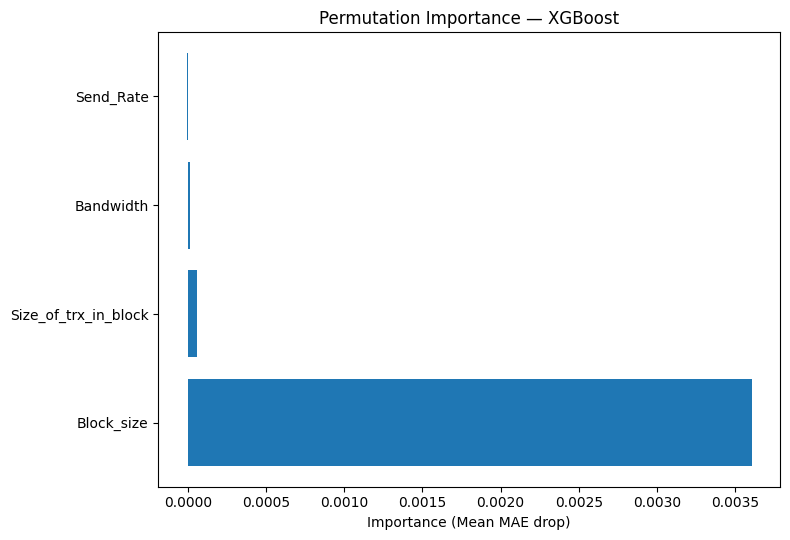

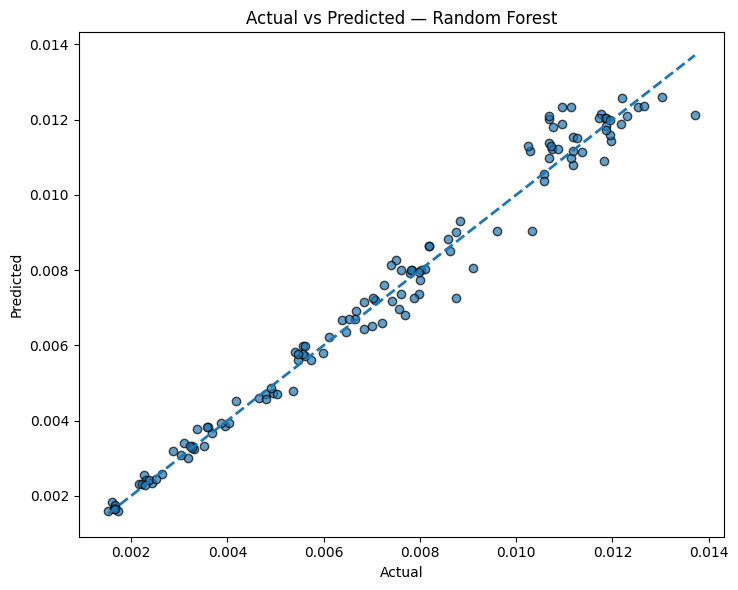

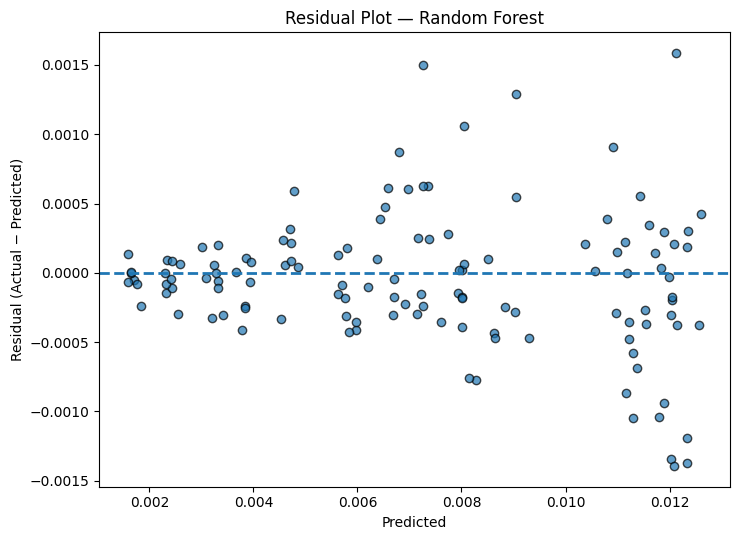

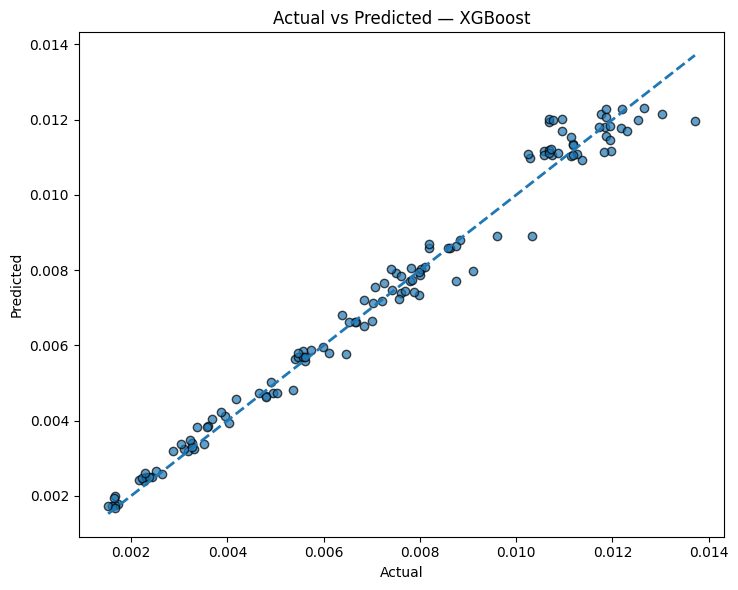

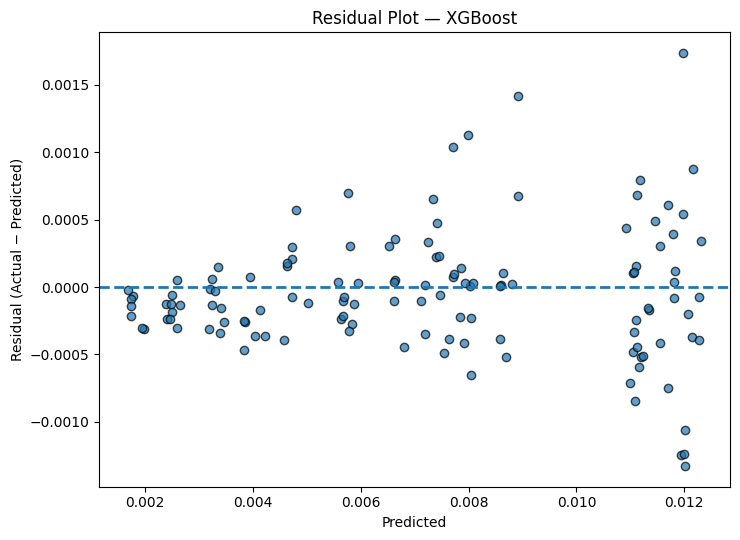

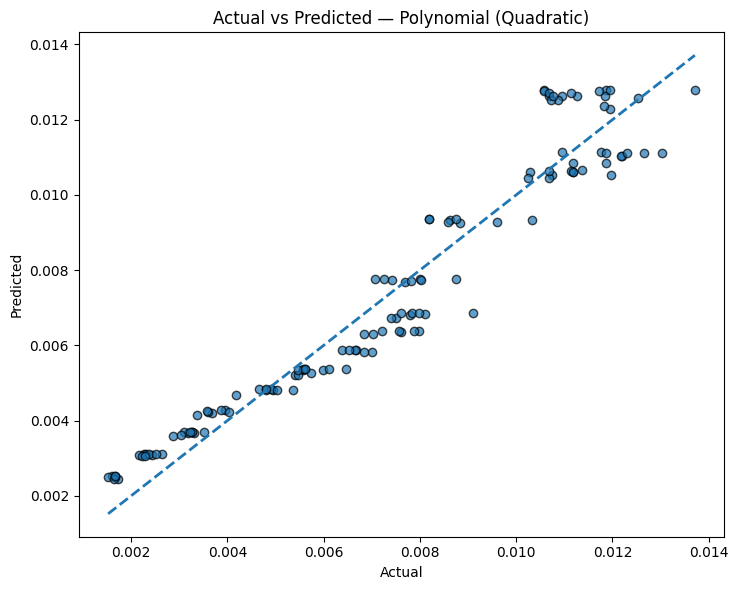

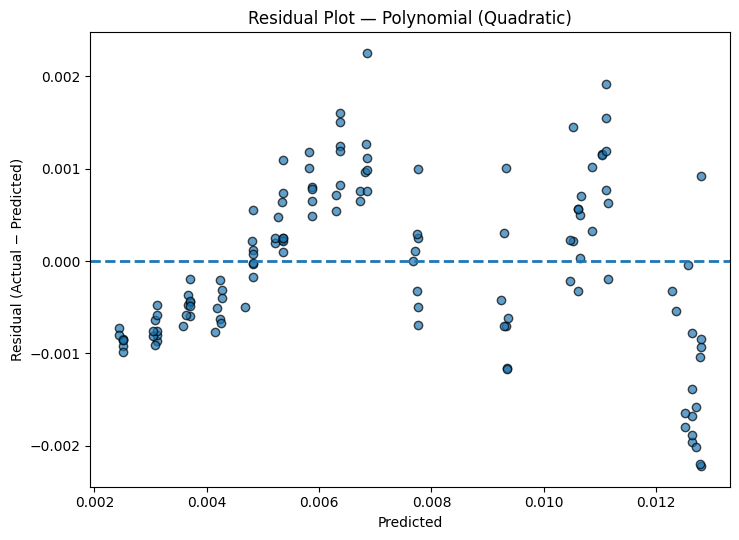

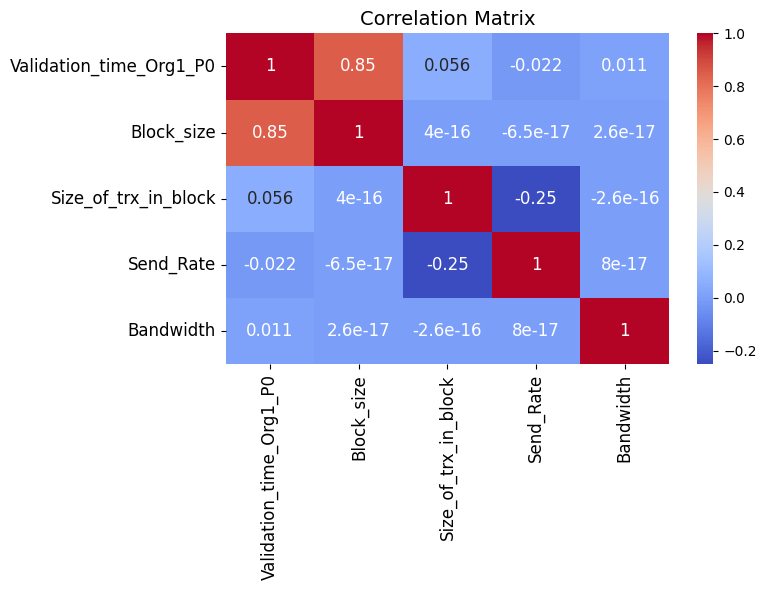

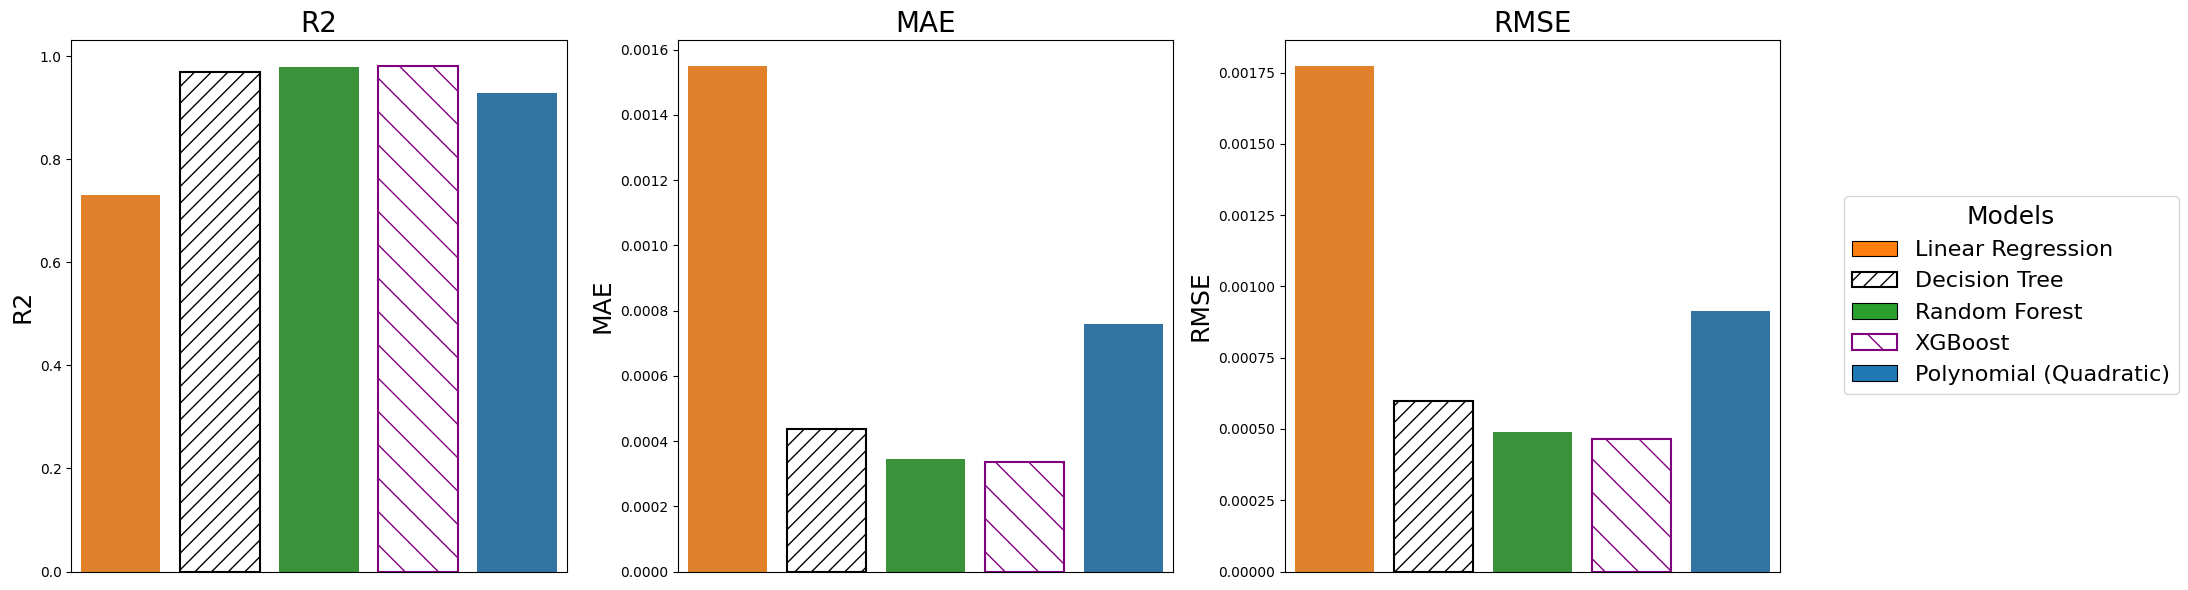

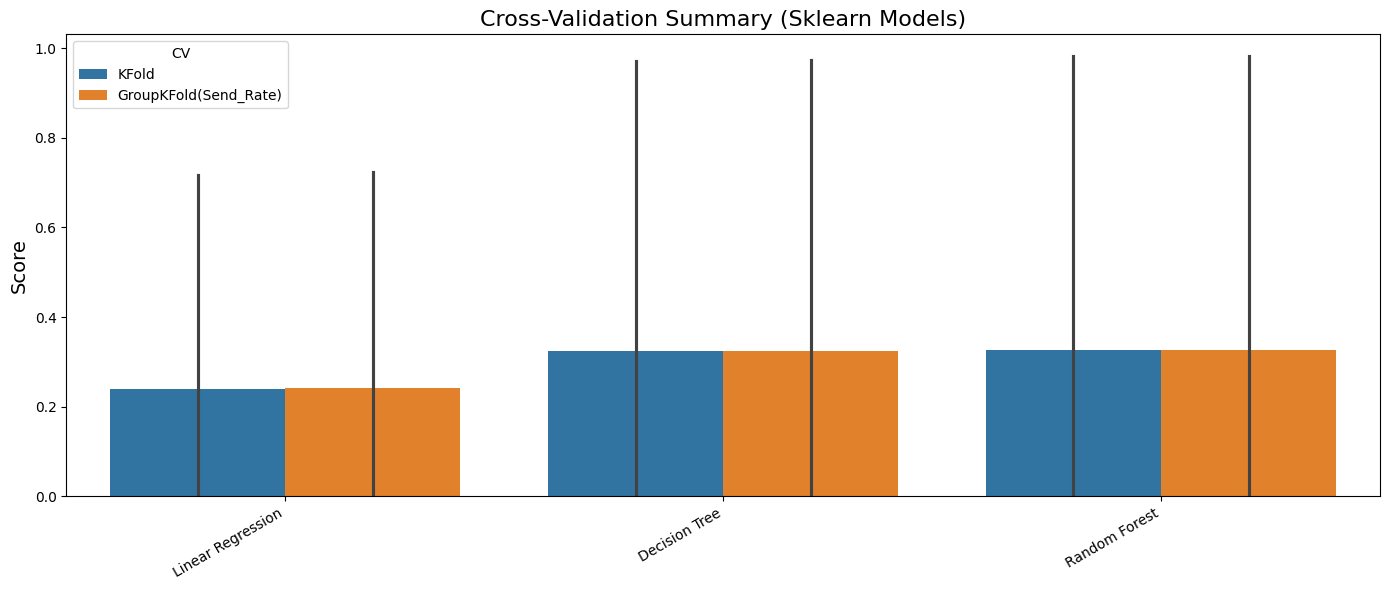


Saved models and quadratic artifacts successfully.


In [4]:
#all model for peer0-Org1 validation time v2  


"""
Model comparison for Validation_time_Org1_P0 (Org1 Peer0)

Goals (publication-friendly):
1) Train multiple regression models on the same feature set.
2) Report test-set metrics (MAE, RMSE, MSE, R2, MAPE) + simple baselines.
3) Run cross-validation:
   - KFold (random) for overall stability
   - GroupKFold (group by Send_Rate) to test generalization to unseen workload rates
4) Provide clean, consistent, high-quality plots:
   - Actual vs Predicted
   - Residual plots (diagnostic)
   - Metric comparison bars (MSE/R2/MAPE and MAE/RMSE/R2)
   - CV summary plot (MAE/RMSE/R2 from KFold and GroupKFold)

Notes on scaling:
- Tree-based models (DecisionTree/RandomForest/GBR/HGBR/XGBoost) do NOT require feature scaling.
- Linear regression benefits from scaling only when regularization is used; plain LinearRegression is fine.
- Quadratic curve_fit DOES benefit from scaling (we scale only inside that block, without leakage).

Assumptions:
- df is already loaded and contains:
  Block_size, Size_of_trx_in_block, Send_Rate, Bandwidth, Validation_time_Org1_P0
"""

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'pdf.fonttype': 42})

from sklearn.model_selection import train_test_split, KFold, GroupKFold, cross_validate
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.dummy import DummyRegressor

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

from sklearn.preprocessing import StandardScaler

from scipy.optimize import curve_fit
import xgboost as xgb

import matplotlib.patches as mpatches


# -----------------------------
# Helper metrics + plotting
# -----------------------------
def mean_absolute_percentage_error_safe(y_true, y_pred):
    """MAPE (%) ignoring zero targets to avoid division by zero."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)

def metrics_dict(y_true, y_pred):
    """Return standard regression metrics in a consistent dict."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error_safe(y_true, y_pred)
    return {"MAE": float(mae), "RMSE": rmse, "MSE": float(mse), "R2": float(r2), "MAPE(%)": float(mape)}

def plot_actual_vs_predicted(y_true, y_pred, model_name, save_pdf=False):
    plt.figure(figsize=(7.5, 6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolors='k')
    mn = min(np.min(y_true), np.min(y_pred))
    mx = max(np.max(y_true), np.max(y_pred))
    plt.plot([mn, mx], [mn, mx], '--', linewidth=2)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'Actual vs Predicted — {model_name}')
    plt.tight_layout()
    if save_pdf:
        plt.savefig(f'actual_vs_pred_{model_name.replace(" ", "_")}.pdf', dpi=600)
    plt.show()

def plot_residuals(y_true, y_pred, model_name, save_pdf=False):
    residuals = np.asarray(y_true) - np.asarray(y_pred)
    plt.figure(figsize=(7.5, 5.5))
    plt.scatter(y_pred, residuals, alpha=0.7, edgecolors='k')
    plt.axhline(0, linestyle='--', linewidth=2)
    plt.xlabel('Predicted')
    plt.ylabel('Residual (Actual − Predicted)')
    plt.title(f'Residual Plot — {model_name}')
    plt.tight_layout()
    if save_pdf:
        plt.savefig(f'residuals_{model_name.replace(" ", "_")}.pdf', dpi=600)
    plt.show()

def styled_metric_bars(plot_df, metric_names, title, filename_pdf, model_colors, hatch_rules):
    """
    Publication-friendly bar chart (one row per model, one panel per metric).
    Uses consistent colors and hatches for selected models.
    """
    melted = plot_df.melt(id_vars='Models', value_vars=metric_names, var_name='Metric', value_name='Score')

    plt.figure(figsize=(18, 6))
    for i, metric in enumerate(metric_names, 1):
        plt.subplot(1, len(metric_names), i)
        ax = sns.barplot(
            x='Models', y='Score',
            data=melted.query("Metric == @metric"),
            palette=[model_colors.get(m, '#FFFFFF') for m in plot_df['Models'].tolist()],
            hue='Models', dodge=False, legend=False
        )

        # Apply hatches/edges
        for bar, model in zip(ax.patches, plot_df['Models'].tolist()):
            hatch, face_none, edge_color, lw = hatch_rules.get(model, ("", False, None, 0.8))
            bar.set_hatch(hatch)

            if face_none:
                bar.set_facecolor('none')
            if edge_color is not None:
                bar.set_edgecolor(edge_color)
            bar.set_linewidth(lw)

        plt.title(metric, fontsize=20)
        plt.ylabel(metric, fontsize=18)
        plt.xlabel('')
        plt.xticks([], [])  # clean style like your old plot

    # Legend (custom, consistent with styles)
    legend_handles = []
    for m in plot_df['Models'].tolist():
        hatch, face_none, edge_color, lw = hatch_rules.get(m, ("", False, "black", 0.8))
        fc = 'none' if face_none else model_colors.get(m, '#FFFFFF')
        ec = edge_color if edge_color is not None else 'black'
        legend_handles.append(mpatches.Patch(facecolor=fc, edgecolor=ec, linewidth=lw, hatch=hatch, label=m))

    plt.gcf().legend(
        handles=legend_handles,
        loc='center',
        bbox_to_anchor=(1.12, 0.5),
        fontsize=16,
        title='Models',
        title_fontsize=18
    )

    plt.tight_layout()
    plt.savefig(filename_pdf, format='pdf', dpi=600, bbox_inches='tight')
    plt.show()


# -----------------------------
# 0) Data / Features
# -----------------------------
# df must exist already
# df.head()

feature_cols = ['Block_size', 'Size_of_trx_in_block', 'Send_Rate', 'Bandwidth']
target_col = 'Validation_time_Org1_P0'

X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# 1) Baselines (sanity checks)
# -----------------------------
baseline_mean = DummyRegressor(strategy="mean")
baseline_mean.fit(X_train, y_train)
pred_mean = baseline_mean.predict(X_test)
print("Baseline (mean):", metrics_dict(y_test, pred_mean))

baseline_block_only = LinearRegression()
baseline_block_only.fit(X_train[['Block_size']], y_train)
pred_block_only = baseline_block_only.predict(X_test[['Block_size']])
print("Baseline (Block_size only):", metrics_dict(y_test, pred_block_only))


# -----------------------------
# 2) Train models (same split)
# -----------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    # XGBoost: keep sklearn wrapper for train/test evaluation
    "XGBoost": xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9
    ),
}

test_results = {}
y_preds = {}

for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    pred = mdl.predict(X_test)
    y_preds[name] = pred
    test_results[name] = metrics_dict(y_test, pred)

print("\n=== Test-set results (single split) ===")
for name in models.keys():
    r = test_results[name]
    print(f"\n{name}:")
    print(f"  MAE:     {r['MAE']:.10f}")
    print(f"  RMSE:    {r['RMSE']:.10f}")
    print(f"  MSE:     {r['MSE']:.10e}")
    print(f"  R2:      {r['R2']:.6f}")
    print(f"  MAPE(%): {r['MAPE(%)']:.4f}")


# -----------------------------
# 3) Quadratic regression (2 features) without leakage (curve_fit)
# -----------------------------
# This is a parametric baseline you can interpret and print as an equation.
quad_features = ['Block_size', 'Send_Rate']

def quadratic_model(X_arr, a, b, c, d, e, f):
    x1, x2 = X_arr
    return a * x1**2 + b * x1 * x2 + c * x2**2 + d * x1 + e * x2 + f

scaler_quad = StandardScaler()
X_train_q = scaler_quad.fit_transform(X_train[quad_features])
X_test_q = scaler_quad.transform(X_test[quad_features])

params, covariance = curve_fit(quadratic_model, X_train_q.T, y_train.values)
a, b, c, d, e, f = params

pred_quad = quadratic_model(X_test_q.T, *params)
test_results["Polynomial (Quadratic)"] = metrics_dict(y_test, pred_quad)
y_preds["Polynomial (Quadratic)"] = pred_quad

equation_scaled = (
    f"Validation_time = ({a:.6g} * x1^2) + ({b:.6g} * x1*x2) + ({c:.6g} * x2^2) "
    f"+ ({d:.6g} * x1) + ({e:.6g} * x2) + ({f:.6g}), "
    f"where x1,x2 are StandardScaler-transformed Block_size, Send_Rate."
)

print("\nPolynomial (Quadratic) equation (on standardized features):")
print(equation_scaled)


# -----------------------------
# 4) Cross-validation (publishable stability)
# -----------------------------
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

cv_kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# GroupKFold: generalize to unseen Send_Rate conditions
groups = df["Send_Rate"].astype(str)
cv_group = GroupKFold(n_splits=min(3, df["Send_Rate"].nunique()))

cv_summary = []

# IMPORTANT: sklearn cross_validate may fail with XGBoost+new sklearn in some environments.
# To keep this script robust + publishable: we do sklearn CV for sklearn models,
# and XGBoost CV using xgb.cv (official).
for name, mdl in models.items():
    if name == "XGBoost":
        continue

    out_k = cross_validate(mdl, X, y, cv=cv_kfold, scoring=scoring, return_train_score=False)
    out_g = cross_validate(mdl, X, y, cv=cv_group, groups=groups, scoring=scoring, return_train_score=False)

    cv_summary.append({
        "Models": name,
        "CV": "KFold",
        "MAE": float(-out_k["test_MAE"].mean()),
        "RMSE": float(-out_k["test_RMSE"].mean()),
        "R2": float(out_k["test_R2"].mean()),
    })
    cv_summary.append({
        "Models": name,
        "CV": "GroupKFold(Send_Rate)",
        "MAE": float(-out_g["test_MAE"].mean()),
        "RMSE": float(-out_g["test_RMSE"].mean()),
        "R2": float(out_g["test_R2"].mean()),
    })

# XGBoost CV (robust, official)
dtrain = xgb.DMatrix(X.values, label=y.values)
params_xgb = {
    "objective": "reg:squarederror",
    "seed": 42,
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
}
cv_xgb = xgb.cv(
    params=params_xgb,
    dtrain=dtrain,
    num_boost_round=800,
    nfold=5,
    metrics=("rmse",),
    early_stopping_rounds=30,
    seed=42,
    verbose_eval=False
)
xgb_rmse = float(cv_xgb["test-rmse-mean"].iloc[-1])

print("\nXGBoost 5-fold CV (xgb.cv):")
print("  RMSE mean (last):", xgb_rmse)
print("  RMSE std  (last):", float(cv_xgb["test-rmse-std"].iloc[-1]))


cv_df = pd.DataFrame(cv_summary)
print("\n=== CV summary (sklearn models) ===")
print(cv_df)


# -----------------------------
# 5) Permutation importance (more reliable than tree impurity importance)
# -----------------------------
# Choose a best model for importance (example: XGBoost)
best_model_name = "XGBoost"
best_model = models["XGBoost"]

perm = permutation_importance(
    best_model,
    X_test, y_test,
    n_repeats=25,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

perm_imp = pd.DataFrame({
    "Feature": X_test.columns,
    "ImportanceMean(MAE drop)": perm.importances_mean,
    "ImportanceStd": perm.importances_std
}).sort_values("ImportanceMean(MAE drop)", ascending=False)

print("\nPermutation importance (MAE drop):")
print(perm_imp)

# Plot permutation importances
plt.figure(figsize=(8, 5.5))
plt.barh(perm_imp["Feature"], perm_imp["ImportanceMean(MAE drop)"])
plt.xlabel("Importance (Mean MAE drop)")
plt.title(f"Permutation Importance — {best_model_name}")
plt.tight_layout()
plt.savefig("permutation_importance.pdf", dpi=600)
plt.show()


# -----------------------------
# 6) Publication plots
# -----------------------------
# 6.1 Actual vs predicted + residuals (pick top models)
for nm in ["Random Forest", "XGBoost", "Polynomial (Quadratic)"]:
    plot_actual_vs_predicted(y_test, y_preds[nm], nm, save_pdf=True)
    plot_residuals(y_test, y_preds[nm], nm, save_pdf=True)

# 6.2 Keep your correlation plot (optional)
corr_cols = [target_col] + feature_cols
correlation_matrix = df[corr_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws={"size": 12})
plt.title("Correlation Matrix", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('validation_correlation_matrix.pdf', format='pdf', dpi=600)
plt.show()

# 6.3 Metric comparison plots (bars) in your style (colors + hatches)
# Build a single test-results table for plotting
plot_models_order = [
    "Linear Regression",
    "Decision Tree",
    "Random Forest",
    "XGBoost",
    "Polynomial (Quadratic)"
]
plot_table = pd.DataFrame([
    {"Models": m,
     "MSE": test_results[m]["MSE"],
     "R2": test_results[m]["R2"],
     "MAPE": test_results[m]["MAPE(%)"],
     "MAE": test_results[m]["MAE"],
     "RMSE": test_results[m]["RMSE"]}
    for m in plot_models_order
])

# Colors (keep your original palette idea + add for GBR/HGBR)
model_colors = {
    "Linear Regression": "#ff7f0e",
    "Decision Tree": "none",
    "Random Forest": "#2ca02c",
    "XGBoost": "none",
    "Polynomial (Quadratic)": "#1f77b4",
}

# Hatch rules: (hatch, face_none, edge_color, linewidth)
hatch_rules = {
    "Decision Tree": ("//", True, "black", 1.5),
    "XGBoost": ("\\", True, "#800080", 1.5),

    # others default
}

# Plot A: your original trio (MSE, R2, MAPE)
styled_metric_bars(
    plot_df=plot_table[["Models", "R2", "MAE", "RMSE"]],
    metric_names=["R2","MAE", "RMSE"],
    title="Model Comparison (Test Set)",
    filename_pdf="validation_models_mse_r2_mape.pdf",
    model_colors=model_colors,
    hatch_rules=hatch_rules
)



# 6.4 CV summary plot (KFold vs GroupKFold)
if not cv_df.empty:
    # Pivot into long format for plotting
    cv_plot = cv_df.melt(id_vars=["Models", "CV"], value_vars=["MAE", "RMSE", "R2"],
                         var_name="Metric", value_name="Score")

    plt.figure(figsize=(14, 6))
    ax = sns.barplot(data=cv_plot, x="Models", y="Score", hue="CV")
    plt.title("Cross-Validation Summary (Sklearn Models)", fontsize=16)
    plt.ylabel("Score", fontsize=14)
    plt.xlabel("")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig("cv_summary.pdf", dpi=600)
    plt.show()


# -----------------------------
# 7) Save fitted models/objects (for reuse)
# -----------------------------
import joblib

joblib.dump(models["Linear Regression"], "VP0_linear_model.pkl")
joblib.dump(models["Decision Tree"], "VP0_tree_model.pkl")
joblib.dump(models["Random Forest"], "VP0_forest_model.pkl")
joblib.dump(models["XGBoost"], "VP0Org1_xgboost_model.pkl")

# Quadratic params + scaler for later prediction
joblib.dump(params, "VP0_quadratic_params.pkl")
joblib.dump(scaler_quad, "VP0_quadratic_scaler.pkl")

print("\nSaved models and quadratic artifacts successfully.")

